## Librerias

In [1]:
import geopandas as gpd
import fiona
import matplotlib.pyplot as plt
import folium
from IPython.display import IFrame
from IPython.display import display
from shapely.geometry import LineString
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from ipywidgets import Dropdown
from ipywidgets import interact
import numpy as np
import time
import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import LineString
from shapely.ops import substring

fiona.drvsupport.supported_drivers['kml'] = 'rw' # enable KML support which is disabled by default
fiona.drvsupport.supported_drivers['KML'] = 'rw' # enable KML support which is disabled by default


## Operaciones en el Mapa

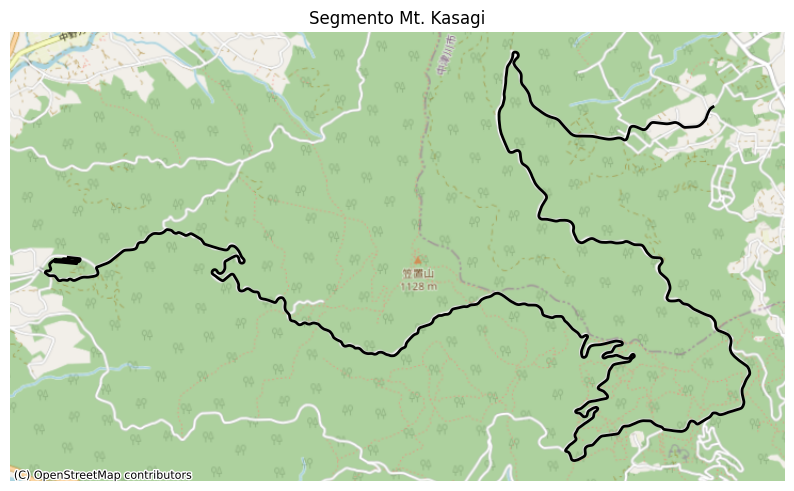

In [3]:
# Abre el archivo KML y lista las capas disponibles
filename = "FORUM8 Rally Japan 2024.kml"
# Carga las diferentes layers que tiene el archivo, en este caso los diferentes Secciones de la ruta.
layers = fiona.listlayers(filename)
# Carga la layer que seleccionemos
selected_layer = layers[3]
gdf = gpd.read_file(filename, driver="KML", layer=selected_layer)
# Actualizamos la sección para medir las distancias de forma correcta
gdf = gdf.to_crs(epsg=3857)
# Convertimos el gdf a una lista en caso de que sea necesaria para plotear los diferentes segmentos de la sección
gdf_list = [gdf.iloc[[i]] for i in range(len(gdf))]
draw_section = False
# Dibujamos las secciones
if draw_section:
    fig, axs = plt.subplots(1, len(gdf_list), figsize=(10 * len(gdf_list), 10 ))
    fig.suptitle(selected_layer, fontsize=16)

    if len(gdf_list) == 1:
        gdf_list[0].plot(ax=axs, color="black", lw=4)
        axs.set_title(f"Seccion {1}, {gdf_list[0].iloc[0]['Name']}")
        axs.axis("off")
    else:
        for i, gdf_part in enumerate(gdf_list):
            gdf_list[i].plot(ax=axs[i], color="black", lw=4)
            axs[i].set_title(f"Parte {i+1}, {gdf_list[i].iloc[0]['Name']}")
            axs[i].axis("off")

# Cargamos los segmentos por separado
gdf_list_names = [gdf.iloc[i]["Name"] for i in range(len(gdf))]
selected_segment = gdf_list_names[0]
gdf_segment = gdf[gdf["Name"] == selected_segment].to_crs(epsg=3099)
gdf_segment["length_m"] = gdf_segment["geometry"].length
length_m = gdf_segment["length_m"].iloc[0]

# Dibujamos el segmento seleccionado con el mapa de fondo
# providers = list(ctx.providers.keys()) # Lista de los diferentes providers que podemos usar, para ver dentro de cada uno usar tambien .keys()
# print(providers)
draw_segment = True
if draw_segment:
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    gdf_segment.plot(ax=ax, color="black", lw=2)
    ctx.add_basemap(ax, crs=gdf_segment.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)
    ax.set_title(f"Segmento {selected_segment}")
    ax.axis("off")

## Creación de la leyenda

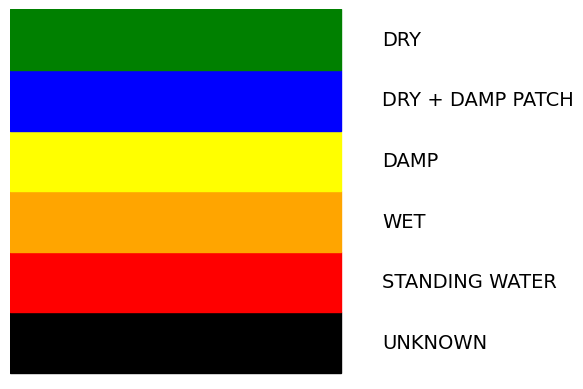

In [4]:
# Diccionario con Significado como key y Color en notación HEX como value
legend_dict = {
    'Dry': '#008000',
    'Dry + Damp Patch': '#0000FF',
    'Damp': '#FFFF00',
    'Wet': '#FFA500',
    'Standing Water': '#FF0000',
    'Unknown': '#000000'
}
draw_legend = True
if draw_legend:

    # Crear la figura y el eje
    fig, ax = plt.subplots()

    # Añadir los rectángulos de la leyenda (2/3 de ancho) y el texto (1/3 de ancho)
    for idx, (label, color) in enumerate(reversed(list(legend_dict.items()))):
        rect = plt.Rectangle((0, idx), 4, 1, color=color)
        ax.add_patch(rect)
        ax.text(4.5, idx + 0.5, label.upper(), verticalalignment='center', fontsize=14, horizontalalignment='left')

    ax.set_xlim(0, 4 + 2)  # rectangle width (4) plus margin
    ax.set_ylim(-.1, len(legend_dict))
    ax.axis('off')

    plt.show()

## Creación de los diferentes tramos del segment

In [5]:
def split_line_variable_lengths(gdf_segment, segment_lengths, start_distance=0, end_distance = None):
    """
    Divide una línea en segmentos de longitudes variables especificadas en un array.
    
    Parameters:
        gdf_segment (GeoDataFrame): GeoDataFrame con un único LineString en la columna 'geometry'.
        segment_lengths (list): Lista con las longitudes de cada segmento.
    
    Returns:
        GeoDataFrame: Nuevo GeoDataFrame con los segmentos generados.
    """
    # Obtener la geometría (LineString) y la longitud total
    line = gdf_segment.geometry.iloc[0]
    total_length = gdf_segment.length_m.iloc[0]

    # Verificar si la línea es válida
    if not isinstance(line, LineString):
        return gdf_segment  # Si no es una línea válida, devolvemos el mismo gdf

    # Ajustar la distancia final si no se especifica
    if end_distance is None or end_distance > total_length:
        end_distance = total_length  # Asegurarnos de no sobrepasar la longitud real de la línea

    # Lista para almacenar los segmentos resultantes
    segments_list = []
    current_distance = max(0, start_distance)  # Asegurar que no sea menor que 0

    # Iteramos sobre los segmentos
    for segment in segment_lengths:
        # Calculamos la distancia final del segmento
        next_distance = min(segment['end'], end_distance)  # No pasarnos del límite definido

        # Extraemos el segmento de la línea respetando la curvatura
        segment_geom = substring(line, segment['start'], next_distance)
        segments_list.append(segment_geom)

        # Avanzamos la distancia inicial para el próximo segmento
        current_distance = next_distance

        # Si llegamos al final, rompemos el loop
        if current_distance >= end_distance:
            break

    # Crear un nuevo GeoDataFrame con los segmentos
    new_gdf = gpd.GeoDataFrame(geometry=segments_list, crs=gdf_segment.crs)

    return new_gdf

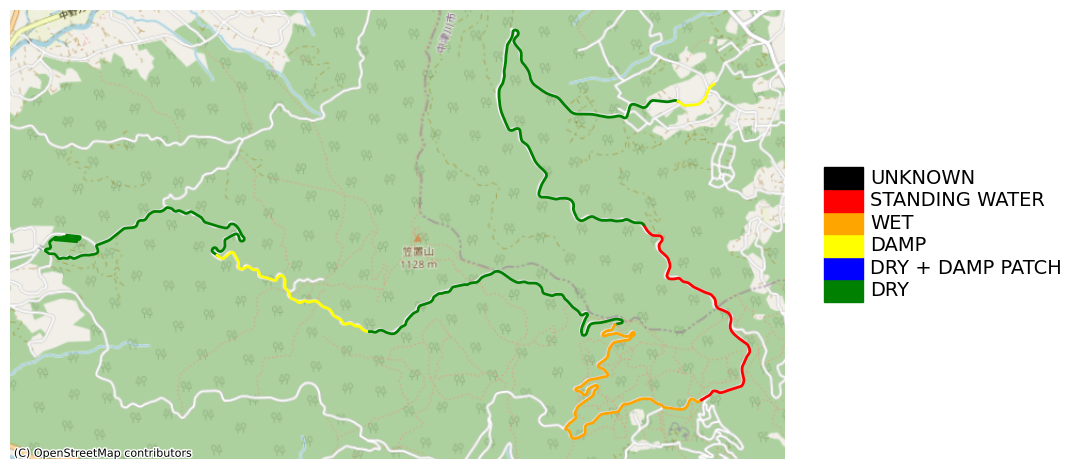

In [7]:

# Uso de la función con longitudes variables
subsegment_lengths = [1000, 2000, 1500, 2500,3000,2000,4000,3000]  # Longitudes en metros
segments = [{'start': 0, 'end': 1000, 'type': ''},
            {'start': 1000, 'end': 3000, 'type': ''},
            {'start': 3000, 'end': 4500, 'type': ''},
            {'start': 4500, 'end': 7000, 'type': ''},
            {'start': 7000, 'end': 10000, 'type': ''},
            {'start': 10000, 'end': 12000, 'type': ''},
            {'start': 12000, 'end': 16000, 'type': ''},
            {'start': 16000, 'end': 19000, 'type': ''}]

segments_start = segments[0]['start']
segments_end = segments[-1]['end']

# Crear un diccionario que asocie cada segmento con un color
segment_colors = {
    0: 'Dry',
    1: 'Dry',
    2: 'Damp',
    3: 'Dry',
    4: 'Wet',
    5: 'Standing Water',
    6: 'Dry',
    7: 'Damp',
}



# Asignar los tipos a los segmentos
for i, segment in enumerate(segments):
    segment['type'] = segment_colors[i]

gdf_subsegments = split_line_variable_lengths(gdf_segment, segments, start_distance= segments_start, end_distance=segments_end)
gdf_subsegments = gdf_subsegments.geometry

draw_subsegments = True
    
# Asignar colores a los segmentos basados en su tipo
for segment in segments:
    segment["color"] = legend_dict[segment["type"]]

# Dibujar los subsegmentos con los colores asociados
draw_subsegments = True
if draw_subsegments:
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    for i, geom in enumerate(gdf_subsegments):
        x, y = geom.xy
        ax.plot(x, y, color=segments[i]["color"], linewidth=2)
    ax.set_aspect("equal")
    ctx.add_basemap(ax, crs=gdf_subsegments.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)
    ax.axis("off")
    # Añadir la leyenda a la derecha del gráfico
    legend_x = 1.05
    legend_y = 0.5 - len(legend_dict) * 0.025  # Centrar verticalmente
    for idx, (label, color) in enumerate(legend_dict.items()):
        rect = plt.Rectangle((legend_x, legend_y + idx * 0.05), 0.05, 0.05, color=color, transform=ax.transAxes, clip_on=False)
        ax.add_patch(rect)
        ax.text(legend_x + 0.06, legend_y + idx * 0.05 + 0.025, label.upper(), verticalalignment='center', fontsize=14, horizontalalignment='left', transform=ax.transAxes)


    plt.show()

